# LSTM to Predict Water Leakage
- From climate data

# Imports and Data Read-In

In [476]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
from torchinfo import summary
import datetime

dataPath = os.path.join(os.getcwd(), '..', "data", 'weekly_min_max.csv')

df = pd.read_csv(dataPath, parse_dates=['date'])
df.set_index('date', inplace=True)

# Configuration

In [477]:
FEATURE_COLS = ["temperature_2m_min", "soil_temperature_28_to_100cm_min", "soil_moisture_28_to_100cm_min", "precipitation_min", 
                "temperature_2m_max", "soil_temperature_28_to_100cm_max", "soil_moisture_28_to_100cm_max", "precipitation_max", 
                'water_leakage']
TARGET_COL   = "water_leakage"

# Hyperparameters

In [478]:
SEQ_LEN      = 4 #4     # look-back window (weeks)
BATCH_SIZE   = 8 #8
HIDDEN_SIZE  = 32
NUM_LAYERS   = 1
DROPOUT      = 0.4
LEARNING_RATE = 5e-4
EPOCHS       = 50
TEST_SIZE    = 0.2     # fraction of data held out for testing
VAL_SIZE     = 0.1     # fraction of training data used for validation
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


# LSTM Definition

In [479]:
class LeakageLSTM(nn.Module):
    """
    Stacked LSTM followed by a fully-connected regression head.
    """
    def __init__(self, input_size: int, hidden_size: int,
                 num_layers: int, dropout: float):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            #nn.Linear(64, 32),
            #nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)          # out: (batch, seq_len, hidden_size)
        last    = out[:, -1, :]        # take the last time step
        return self.head(last).squeeze(-1)

## Train Function

In [480]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        #print(x, y)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset), pred, y

## Evaluate Function

In [481]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    preds, trues = [], []
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x)
        total_loss += criterion(pred, y).item() * len(y)
        preds.append(pred.cpu().numpy())
        trues.append(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.concatenate(preds), np.concatenate(trues)

## Prediction Function

In [482]:
def predict(checkpoint_path: str, recent_df: pd.DataFrame) -> float:
    """
    Load a saved model and predict leakage for the NEXT week.

    Parameters
    ----------
    checkpoint_path : str
        Path to the .pt file saved by run().
    recent_df : pd.DataFrame
        At least SEQ_LEN rows of feature data (most recent last),
        with the same FEATURE_COLS columns.

    Returns
    -------
    float : predicted water leakage in original units.
    """
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    cfg  = ckpt["config"]

    model = LeakageLSTM(cfg["input_size"], cfg["hidden_size"],
                        cfg["num_layers"],  cfg["dropout"])
    model.load_state_dict(ckpt["model_state"])
    model.eval()

    feat_scaler   = ckpt["feat_scaler"]
    target_scaler = ckpt["target_scaler"]

    window = recent_df[FEATURE_COLS].values[-cfg["seq_len"]:]
    x      = feat_scaler.transform(window)
    x_t    = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # (1, seq, feat)

    with torch.no_grad():
        pred_scaled = model(x_t).item()

    return target_scaler.inverse_transform([[pred_scaled]])[0][0]

# Dataset Loading

## Sliding Window

In [483]:
class TimeSeriesDataset(Dataset):
    """
    Sliding-window dataset.
    Each sample:  X  →  (SEQ_LEN, n_features)
                  y  →  scalar (leakage at the next time step)
    """
    def __init__(self, features: np.ndarray, targets: np.ndarray, seq_len: int):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets  = torch.tensor(targets,  dtype=torch.float32)
        self.seq_len  = seq_len

    def __len__(self):
        return len(self.features) - self.seq_len

    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]          # (SEQ_LEN, n_features)
        y = self.targets[idx + self.seq_len] # scalar
        #print('inputs:', x)    
        #print('outputs:', y)  
        #print('output series:', self.targets[idx + self.seq_len - 5 : idx + self.seq_len + 5])             
        return x, y

## Scaling

In [484]:
feat_scaler = StandardScaler()
target_scaler = StandardScaler()

# Keep raw arrays unscaled here; scaling is fit on training split only.
raw_features = df[FEATURE_COLS].values
raw_targets = df[[TARGET_COL]].values.ravel()

print(raw_features.shape, raw_targets.shape)

(1261, 9) (1261,)


9 input features:
- 8 climatic
- leakage up until timestep before now (CHECK THIS)

## Splitting

In [485]:
n          = len(raw_features)
n_test     = int(n * TEST_SIZE)
n_val      = int((n - n_test) * VAL_SIZE)
n_train    = n - n_test - n_val

# Time-ordered split (no shuffling for sequence forecasting).
X_train_raw, X_val_raw, X_test_raw = (
    raw_features[:n_train],
    raw_features[n_train:n_train+n_val],
    raw_features[n_train+n_val:],
)
y_train_raw, y_val_raw, y_test_raw = (
    raw_targets[:n_train],
    raw_targets[n_train:n_train+n_val],
    raw_targets[n_train+n_val:],
)

# Fit scalers on TRAIN only to avoid leakage into validation/test.
feat_scaler.fit(X_train_raw)
target_scaler.fit(y_train_raw.reshape(-1, 1))

f_train = feat_scaler.transform(X_train_raw)
f_val   = feat_scaler.transform(X_val_raw)
f_test  = feat_scaler.transform(X_test_raw)

t_train = target_scaler.transform(y_train_raw.reshape(-1, 1)).ravel()
t_val   = target_scaler.transform(y_val_raw.reshape(-1, 1)).ravel()
t_test  = target_scaler.transform(y_test_raw.reshape(-1, 1)).ravel()

print(f"Splits — train: {n_train}, val: {n_val}, test: {n_test}")

Splits — train: 909, val: 100, test: 252


## Loading

In [486]:
train_ds = TimeSeriesDataset(f_train, t_train, SEQ_LEN)
val_ds   = TimeSeriesDataset(f_val,   t_val,   SEQ_LEN)
test_ds  = TimeSeriesDataset(f_test,  t_test,  SEQ_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

# Model Intialisation

In [487]:
model     = LeakageLSTM(len(FEATURE_COLS), HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.SmoothL1Loss()

#print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}\n")
summary(model,input_size=(BATCH_SIZE, SEQ_LEN, len(FEATURE_COLS)),device=str(DEVICE))

Layer (type:depth-idx)                   Output Shape              Param #
LeakageLSTM                              [8]                       --
├─LSTM: 1-1                              [8, 4, 32]                5,504
├─Sequential: 1-2                        [8, 1]                    --
│    └─Dropout: 2-1                      [8, 32]                   --
│    └─Linear: 2-2                       [8, 16]                   528
│    └─ReLU: 2-3                         [8, 16]                   --
│    └─Linear: 2-4                       [8, 1]                    17
Total params: 6,049
Trainable params: 6,049
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.18
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.02
Estimated Total Size (MB): 0.03

# Training Loop

In [488]:
history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state    = None

for epoch in range(1, EPOCHS + 1):
    train_loss, _, _  = train_one_epoch(model, train_dl, optimizer, criterion)
    val_loss, val_pred, val_true = evaluate(model, val_dl, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state    = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
                f"Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

Epoch   1/50 | Train MSE: 0.4051 | Val MSE: 0.3580
Epoch  10/50 | Train MSE: 0.0711 | Val MSE: 0.0990
Epoch  20/50 | Train MSE: 0.0665 | Val MSE: 0.0787
Epoch  30/50 | Train MSE: 0.0601 | Val MSE: 0.0793
Epoch  40/50 | Train MSE: 0.0609 | Val MSE: 0.0757
Epoch  50/50 | Train MSE: 0.0570 | Val MSE: 0.0752


# Evaluation and Inverse Transform

In [489]:
model.load_state_dict(best_state)
test_loss, preds_scaled, trues_scaled = evaluate(model, test_dl, criterion)
train_loss, train_preds_scaled, train_trues_scaled = evaluate(model, train_dl, criterion)

# Inverse-transform back to original units
preds = target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
trues = target_scaler.inverse_transform(trues_scaled.reshape(-1, 1)).ravel()

preds_train = target_scaler.inverse_transform(train_preds_scaled.reshape(-1, 1)).ravel()
trues_train = target_scaler.inverse_transform(train_trues_scaled.reshape(-1, 1)).ravel()

mae  = np.mean(np.abs(preds - trues))
rmse = np.sqrt(np.mean((preds - trues) ** 2))
ss_res = np.sum((trues - preds) ** 2)
ss_tot = np.sum((trues - trues.mean()) ** 2)
r2   = 1 - ss_res / ss_tot

print(f"\n── Test Results ──────────────────────────────")
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")


── Test Results ──────────────────────────────
  MAE  : 406.4268
  RMSE : 506.6217
  R²   : 0.8325


# 4 week predicition

In [ ]:
# ── 7. 4-week-ahead forecast on the test set ──────────────────────────────
# Strategy: for every valid starting position in the test features,
# take the SEQ_LEN window, then autoregressively predict 4 steps forward.
# At each step we append the new prediction as a pseudo-feature row so the
# LSTM always receives a full-length window.
# The real targets 4 steps ahead are then compared to these predictions.

FORECAST_HORIZON = 4   # weeks (~1 month)

model.eval()
four_week_preds, four_week_trues = [], []

# We need at least SEQ_LEN + FORECAST_HORIZON rows in the test block
max_start = len(f_test) - SEQ_LEN - FORECAST_HORIZON

with torch.no_grad():
    for start in range(max_start):
        # Seed window: the SEQ_LEN feature rows before this position
        window = f_test[start : start + SEQ_LEN].copy()   # (SEQ_LEN, n_feat)

        # Autoregressively roll forward FORECAST_HORIZON steps
        for step in range(FORECAST_HORIZON):
            x_t   = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            pred  = model(x_t).item()   # scaled prediction

            if step < FORECAST_HORIZON - 1:
                # Build a pseudo feature row:
                # Here we use real future environmental features (they would
                # be available from a forecast), which is the best-case setup.
                next_feat_row = f_test[start + SEQ_LEN + step].copy()   # (n_feat,)
                # Then replace true future leakage with our own prediction
                # WE ARE ASSUMING THAT THE FEATURE DATA IS ALWAYS THE LAST COLUMN
                next_feat_row[-1] = pred
                # next_feat_row[LEAKAGE_FEAT_IDX] = pred
                window = np.vstack([window[1:], next_feat_row])   # slide window

        # `pred` is now the 4-week-ahead prediction (still scaled)
        pred_real  = target_scaler.inverse_transform([[pred]])[0][0]
        true_real  = target_scaler.inverse_transform(
                        [[t_test[start + SEQ_LEN + FORECAST_HORIZON - 1]]])[0][0]

        four_week_preds.append(pred_real)
        four_week_trues.append(true_real)

four_week_preds = np.array(four_week_preds)
four_week_trues = np.array(four_week_trues)

mae4  = np.mean(np.abs(four_week_preds - four_week_trues))
rmse4 = np.sqrt(np.mean((four_week_preds - four_week_trues) ** 2))
ss_res4 = np.sum((four_week_trues - four_week_preds) ** 2)
ss_tot4 = np.sum((four_week_trues - four_week_trues.mean()) ** 2)
r2_4  = 1 - ss_res4 / ss_tot4

print(f"\n── Test Results (4-week ahead) ───────────────")
print(f"  MAE  : {mae4:.4f}")
print(f"  RMSE : {rmse4:.4f}")
print(f"  R²   : {r2_4:.4f}")


── Test Results (4-week ahead) ───────────────
  MAE  : 586.5516
  RMSE : 750.0785
  R²   : 0.6350


# Free run over the whole of the test data

In [ ]:
# ── 9. Free-running forecast over second half of test set ────────────────
# Seed with real data up to the sequence length, then never correct leakage —
# the model's own predictions are fed back as the leakage feature.
# Environmental features use real future values (as a weather forecast would).

LEAKAGE_FEAT_IDX = FEATURE_COLS.index("water_leakage") \
                    if "water_leakage" in FEATURE_COLS else None


window        = f_test[:SEQ_LEN].copy()
n_free_steps  = len(f_test) - SEQ_LEN


free_preds_scaled = []
model.eval()

with torch.no_grad():
    for step in range(n_free_steps):
        x_t  = torch.tensor(window, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred = model(x_t).item()
        free_preds_scaled.append(pred)

        if step < n_free_steps - 1:
            # Real environmental features for the next row...
            next_row = f_test[SEQ_LEN + step].copy()
            # ...but leakage replaced with our own prediction, not the truth
            if LEAKAGE_FEAT_IDX is not None:
                next_row[LEAKAGE_FEAT_IDX] = pred
            window = np.vstack([window[1:], next_row])

free_preds = target_scaler.inverse_transform(
                np.array(free_preds_scaled).reshape(-1, 1)).ravel()
free_trues = target_scaler.inverse_transform(
                t_test[SEQ_LEN:].reshape(-1, 1)).ravel()

mae_fr  = np.mean(np.abs(free_preds - free_trues))
rmse_fr = np.sqrt(np.mean((free_preds - free_trues) ** 2))
ss_res_fr = np.sum((free_trues - free_preds) ** 2)
ss_tot_fr = np.sum((free_trues - free_trues.mean()) ** 2)
r2_fr   = 1 - ss_res_fr / ss_tot_fr

print(f"\n── Free-Running Forecast (second half of test) ───")
print(f"  Steps forecast : {n_free_steps} weeks")
print(f"  MAE            : {mae_fr:.4f}")
print(f"  RMSE           : {rmse_fr:.4f}")
print(f"  R²             : {r2_fr:.4f}")



── Free-Running Forecast (second half of test) ───
  Steps forecast : 248 weeks
  MAE            : 1215.4913
  RMSE           : 1522.0705
  R²             : -0.5117


# Plots

## Losses

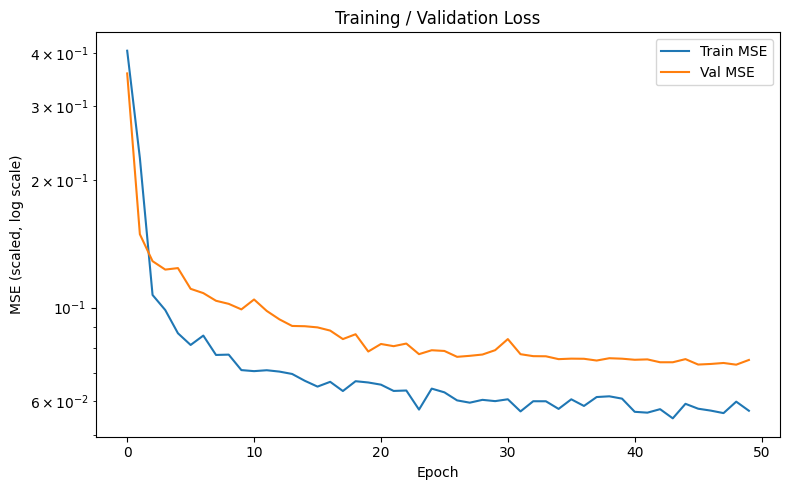

In [490]:
figLoss, axLoss = plt.subplots(figsize=(8, 5))

# Training & validation loss curves

axLoss.plot(history["train_loss"], label="Train MSE")
axLoss.plot(history["val_loss"],   label="Val MSE")
axLoss.set_title("Training / Validation Loss")
axLoss.set_xlabel("Epoch")
axLoss.set_ylabel("MSE (scaled, log scale)")
axLoss.set_yscale("log")
axLoss.legend()

plt.tight_layout()

## Predictions

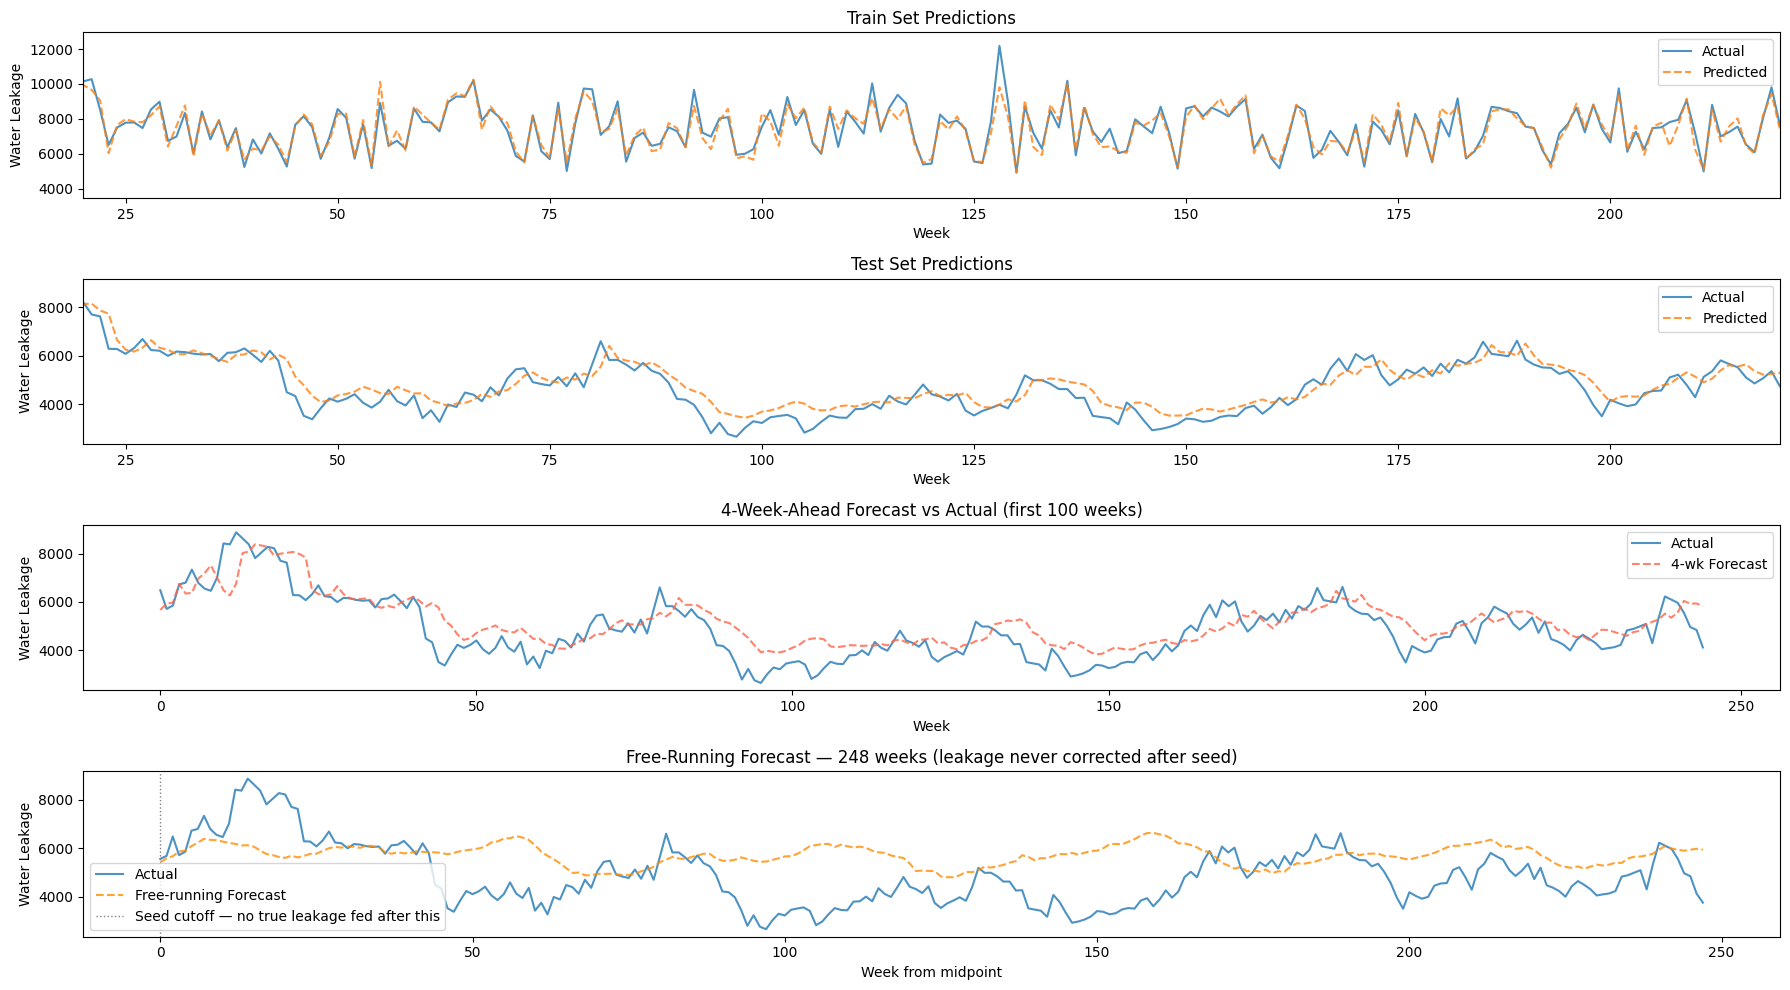

In [491]:
window = 200
offset = np.random.randint(0, max(1, len(trues_train) - window))  # random window for visualization

figPred, axPred = plt.subplots(4, 1, figsize=(18, 10))
# train set predictions vs actual values
axPred[0].plot(trues_train, label="Actual",    alpha=0.8)
axPred[0].plot(preds_train, label="Predicted", alpha=0.8, linestyle="--")
axPred[0].set_title("Train Set Predictions")
axPred[0].set_xlabel("Week")
axPred[0].set_ylabel("Water Leakage")
axPred[0].legend()
axPred[0].set_xlim(offset, min(offset + window, len(trues_train)))


# Test set predictions vs actual values
axPred[1].plot(trues, label="Actual",    alpha=0.8)
axPred[1].plot(preds, label="Predicted", alpha=0.8, linestyle="--")
axPred[1].set_title("Test Set Predictions")
axPred[1].set_xlabel("Week")
axPred[1].set_ylabel("Water Leakage")
axPred[1].legend()
axPred[1].set_xlim(offset if offset + window < len(trues) else 0, min(offset + window, len(trues)))

 # 4-week-ahead predictions
n_show = min(100, len(four_week_preds))
axPred[2].plot(four_week_trues, label="Actual",    alpha=0.8)
axPred[2].plot(four_week_preds, label="4-wk Forecast",
                alpha=0.8, linestyle="--", color="tomato")
axPred[2].set_title("4-Week-Ahead Forecast vs Actual (first 100 weeks)")
axPred[2].set_xlabel("Week")
axPred[2].set_ylabel("Water Leakage")
axPred[2].legend()


# Free-running forecast over full second half of test
weeks = np.arange(n_free_steps)
axPred[3].plot(weeks, free_trues, label="Actual",                alpha=0.8)
axPred[3].plot(weeks, free_preds, label="Free-running Forecast", alpha=0.8,
                linestyle="--", color="darkorange")
axPred[3].axvline(0, color="grey", linestyle=":", linewidth=1,
                label="Seed cutoff — no true leakage fed after this")
axPred[3].set_title(f"Free-Running Forecast — {n_free_steps} weeks "
                    f"(leakage never corrected after seed)")
axPred[3].set_xlabel("Week from midpoint")
axPred[3].set_ylabel("Water Leakage")
axPred[3].legend()

plt.tight_layout()

# Save Model

In [492]:
savePath = os.path.join(os.getcwd(), '..', "models", f'lstm_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pt')

torch.save({
    "model_state":    best_state,
    "feat_scaler":    feat_scaler,
    "target_scaler":  target_scaler,
    "config": {
        "input_size":  len(FEATURE_COLS),
        "hidden_size": HIDDEN_SIZE,
        "num_layers":  NUM_LAYERS,
        "dropout":     DROPOUT,
        "seq_len":     SEQ_LEN,
    },
}, savePath)
print(f"Model saved to {savePath}")

Model saved to c:\Users\yy21473\.GitHubFiles\VKEMS_Water\notebooks\..\models\lstm_20260326_121749.pt


# Predict future leaks using forecast data

In [ ]:
# Load weekly weather forecast (with known historical leakage where available).
forecast_path = os.path.join(os.getcwd(), '..', "data", "forecast_min_max.csv")
forecast_df = pd.read_csv(forecast_path, parse_dates=['date'])
forecast_df.set_index('date', inplace=True)
forecast_df.sort_index(inplace=True)

# Use the best trained weights currently in memory.
model.load_state_dict(best_state)
model.eval()

# pred_df stores the leakage values used as recursive inputs (actual when known, predicted when unknown).
pred_df = forecast_df.copy()
pred_df['predicted_water_leakage'] = np.nan

# Last date with known measured leakage.
last_known_date = forecast_df[TARGET_COL].last_valid_index()
if last_known_date is None:
    raise ValueError("No known historical leakage values found in forecast_min_max.csv")

if len(pred_df) <= SEQ_LEN:
    raise ValueError(
        f"Need more than {SEQ_LEN} rows in forecast_min_max.csv to run sliding-window prediction."
    )

for pos in range(SEQ_LEN, len(pred_df)):
    ts = pred_df.index[pos]

    # Sliding window uses the previous SEQ_LEN rows. For future dates, these rows may already include
    # recursively predicted leakage values from earlier iterations.
    window_df = pred_df.iloc[pos - SEQ_LEN:pos][FEATURE_COLS]
    if window_df[TARGET_COL].isna().any():
        raise ValueError(
            f"Window before {ts} contains missing leakage values; cannot continue recursion."
        )

    x = feat_scaler.transform(window_df.values)
    x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_scaled = model(x_t).item()
    pred_value = target_scaler.inverse_transform([[pred_scaled]])[0][0]

    # Store model prediction for this timestamp (historical + future).
    pred_df.at[ts, 'predicted_water_leakage'] = pred_value

    # If leakage is unknown at this timestamp, fill it recursively for downstream windows.
    if pd.isna(pred_df.at[ts, TARGET_COL]):
        pred_df.at[ts, TARGET_COL] = pred_value

pred_only_df = pred_df[['predicted_water_leakage']].dropna()
print("Predicted leakage series across available window:")
print(pred_only_df)

output_path = os.path.join(os.getcwd(), '..', "data", "forecast_min_max_with_predictions.csv")
pred_df.to_csv(output_path, index=True)
print(f"Saved predictions to {output_path}")

Recursive future leakage predictions:
                           predicted_water_leakage
date                                              
2026-03-01 00:00:00+00:00              4256.506528
2026-03-08 00:00:00+00:00              4290.446025
2026-03-15 00:00:00+00:00              4404.037402
2026-03-22 00:00:00+00:00              4608.693779
2026-03-29 00:00:00+00:00              4845.981223
2026-04-05 00:00:00+00:00              4952.859665
2026-04-12 00:00:00+00:00              5096.697830
Saved recursive predictions to c:\Users\yy21473\.GitHubFiles\VKEMS_Water\notebooks\..\data\forecast_min_max_with_predictions.csv


## Plot

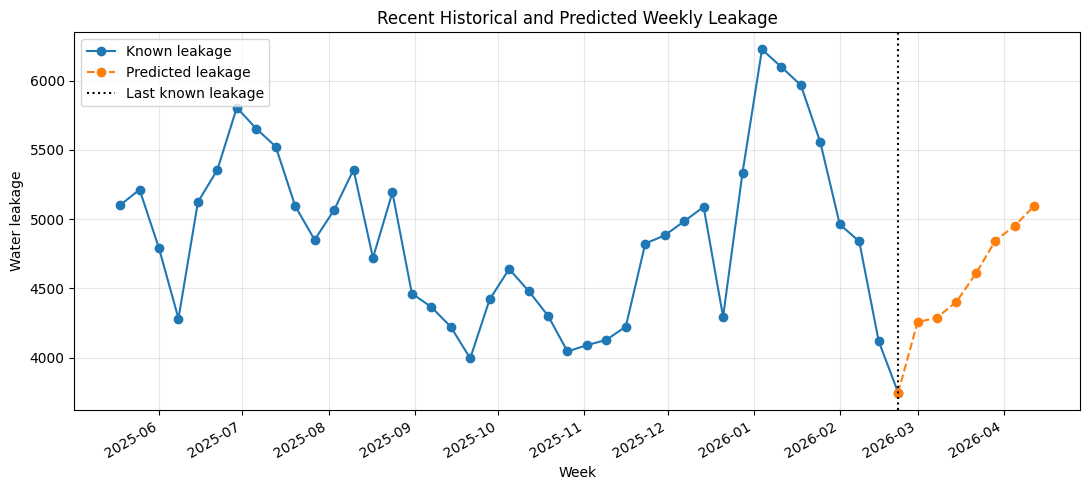

In [ ]:
# Plot known measured leakage and model-predicted leakage across the same time window.
required_cols = {TARGET_COL, 'predicted_water_leakage'}
missing_cols = required_cols.difference(pred_df.columns)
if missing_cols:
    raise ValueError(f"pred_df is missing required columns: {missing_cols}. Run the prediction cell first.")

last_known_date = forecast_df[TARGET_COL].last_valid_index()
if last_known_date is None:
    raise ValueError("No known historical leakage values found in forecast_min_max.csv")

plot_start = pred_df.index.min()
plot_df = pred_df.loc[pred_df.index >= plot_start].copy()

known_series = plot_df[TARGET_COL].where(plot_df.index <= last_known_date)
pred_series = plot_df['predicted_water_leakage']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(known_series.index, known_series.values, marker="o", label="Known leakage")
ax.plot(pred_series.index, pred_series.values, marker="o", linestyle="--", label="Predicted leakage")
ax.axvline(last_known_date, color="black", linestyle=":", linewidth=1.5, label="Last known leakage")

ax.set_title("Known and Predicted Weekly Leakage")
ax.set_xlabel("Week")
ax.set_ylabel("Water leakage")
ax.grid(alpha=0.3)
ax.legend()
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()